# XGBoost Classifier Tutorial

In [1]:
# Required to display widgets in Jupyter
import os
import sys
import pandas as pd

#This will navigate up two levels in the directory structure to the project root directory. 
sys.path.append(os.path.dirname(os.getcwd()))

#Import to minimize warning. 
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

from topicminer import train_test_split_utility, optimize_xgb, train_xgb_classifier, score_xgb_classifier


In [2]:
pd.options.display.max_rows = 100        #Increases the number of rows displayed without a break in the middle.
pd.options.display.max_columns = 100     #Increases the number of columns displayed without a break in the middle.
pd.set_option('max_colwidth',2000)

# Summary of the XGBoost Algorithm

XGBoost is an implementation of gradient boosted decision trees designed for speed and performance.Gradient boosting is an approach where new models are created that predict the residuals or errors of prior models and then added together to make the final prediction. It is called gradient boosting because it uses a gradient descent algorithm to minimize the loss when adding new models. XGBoost is a library designed and optimized for boosting trees algorithms. It is built to be fast. When you have a lot of data and a lot of features, XGBoost is a great choice. It is also a great choice when you have data with a mixture of categorical and numerical features, or when you have a lot of missing data.

# Train/Test Split and Rebalance Data

In [3]:
X_train_bal, X_test, y_train_bal, y_test = train_test_split_utility(
    upsampling_method=None, 
    use_lda_features=True
    )

Shapes - X_train: (3350, 1008), X_test: (1651, 1008), y_train: (3350,), y_test: (1651,)


# Optimize Params

In [4]:
# Returns a dictionary of best parameters
best_params = optimize_xgb(X_train_bal, y_train_bal, scoring='f1', workers = 8) 

|   iter    |  target   | colsam... |   gamma   | learni... | max_depth | min_ch... | n_esti... | subsample |
-------------------------------------------------------------------------------------------------------------


/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=428275) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=428275) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=428275) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=428275) is multi-threaded, use of fork() may lead to deadlocks in the child

| 1         | 0.8872    | 0.5919    | 3.602     | 0.05001   | 3.907     | 2.321     | 109.2     | 0.5931    |
| 2         | 0.8702    | 0.5419    | 1.984     | 0.07694   | 4.258     | 7.167     | 120.4     | 0.9391    |
| 3         | 0.8921    | 0.6023    | 3.478     | 0.05855   | 3.824     | 2.43      | 109.2     | 0.6303    |
| 4         | 0.8963    | 0.6322    | 3.119     | 0.08336   | 3.586     | 2.744     | 109.1     | 0.7379    |
| 5         | 0.876     | 0.3       | 2.877     | 0.05      | 3.259     | 2.175     | 108.6     | 0.5117    |
| 6         | 0.8975    | 0.6344    | 3.122     | 0.08551   | 3.588     | 2.747     | 109.1     | 0.74      |
| 7         | 0.8971    | 0.6648    | 3.152     | 0.1       | 3.618     | 2.777     | 109.1     | 0.7705    |
| 8         | 0.8972    | 0.6498    | 3.135     | 0.1       | 3.662     | 2.705     | 109.1     | 0.7406    |
| 9         | 0.8942    | 0.6293    | 3.215     | 0.1       | 3.59      | 2.726     | 109.1     | 0.7304    |
| 10      

# Train Random Forest Classifier

In [5]:
xgb_clf = train_xgb_classifier(
    X_train_bal, y_train_bal,
    params=best_params,
    workers=8,
)

# Score the classifier

/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/home/aaronnhorvitz/miniconda3/envs/aaron_dev/lib/python3.12/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


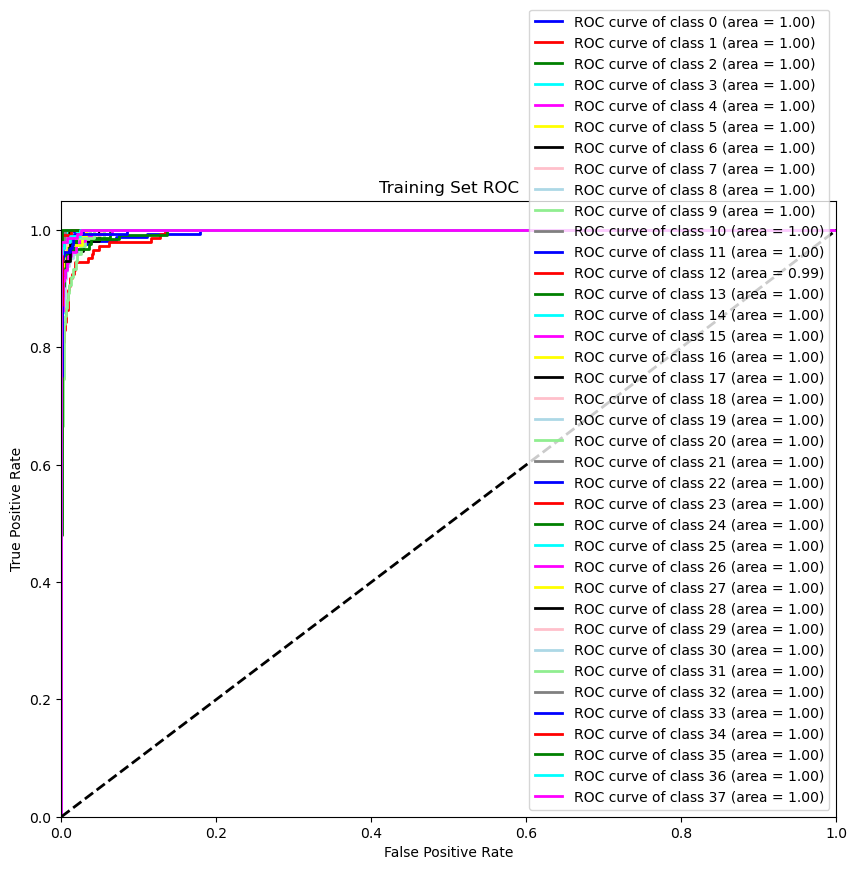

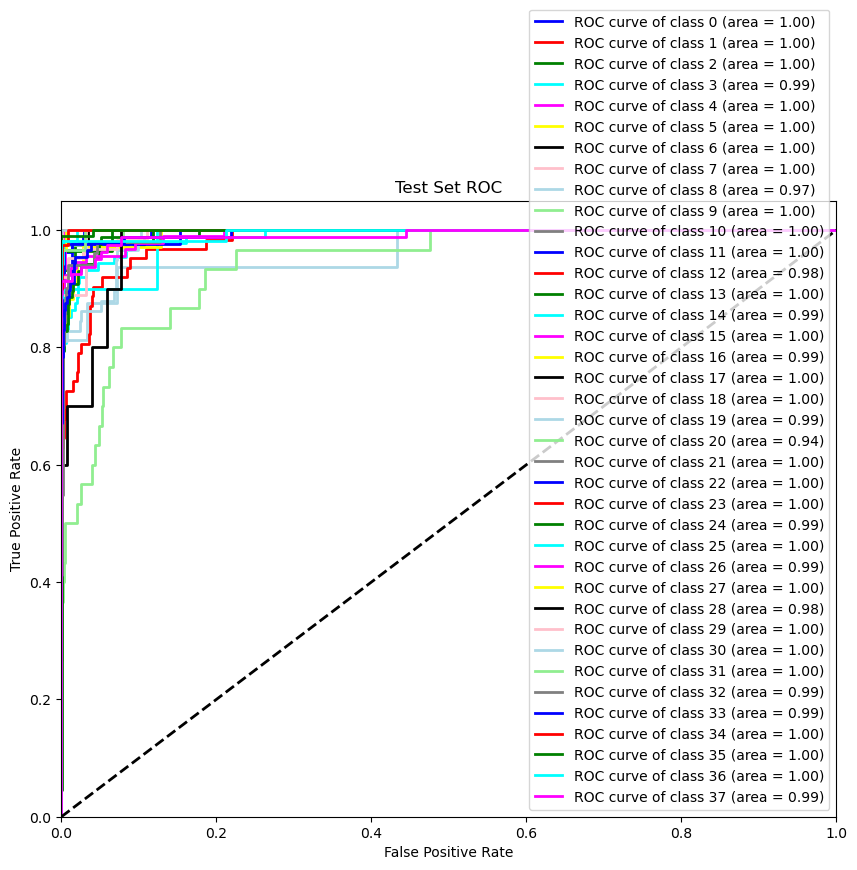

==== Training Metrics ====
Accuracy: 0.9490
F1-Score: 0.9495

==== Testing Metrics ====
Accuracy: 0.9013
F1-Score: 0.9024


In [6]:
score_xgb_classifier(X_train_bal, X_test, y_train_bal, y_test, xgb_clf)